In [ ]:
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
import time

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score

import mlacca_functions as mlcf

In [ ]:
df_path = 'mlacca_outputs\\csv_files\\new_vk_areas_df.csv'
weighted = True

In [3]:
df = pd.read_csv(df_path)

In [4]:
columns_2d = ['O/C','H/C']
X_2d = df[columns_2d].to_numpy()

columns_3d = ['O/C','H/C', 'N/C']
X_3d = df[columns_3d].to_numpy()

y = df['category'].to_numpy()
weights = df['weights'].to_numpy() if weighted else None

In [5]:
param_grid_knn = {
    'n_neighbors': [10,50,100,150,200],
    'weights': ['uniform','distance'],
    }

In [10]:
X_2d_scaled = StandardScaler().fit_transform(X_2d)

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid_knn, refit = True, verbose = 3) 

grid.fit(X_2d_scaled, y)

print('2D KNN best_params_:', grid.best_params_) 
print('2D KNN best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END ...n_neighbors=10, weights=uniform;, score=0.940 total time=   0.0s
[CV 2/5] END ...n_neighbors=10, weights=uniform;, score=0.887 total time=   0.0s
[CV 3/5] END ...n_neighbors=10, weights=uniform;, score=0.915 total time=   0.0s
[CV 4/5] END ...n_neighbors=10, weights=uniform;, score=0.873 total time=   0.0s
[CV 5/5] END ...n_neighbors=10, weights=uniform;, score=0.871 total time=   0.0s
[CV 1/5] END ..n_neighbors=10, weights=distance;, score=0.948 total time=   0.0s
[CV 2/5] END ..n_neighbors=10, weights=distance;, score=0.891 total time=   0.0s
[CV 3/5] END ..n_neighbors=10, weights=distance;, score=0.918 total time=   0.0s
[CV 4/5] END ..n_neighbors=10, weights=distance;, score=0.881 total time=   0.0s
[CV 5/5] END ..n_neighbors=10, weights=distance;, score=0.870 total time=   0.0s
[CV 1/5] END ...n_neighbors=50, weights=uniform;, score=0.938 total time=   0.0s
[CV 2/5] END ...n_neighbors=50, weights=uniform;

In [12]:
X_3d_scaled = StandardScaler().fit_transform(X_3d)

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid_knn, refit = True, verbose = 3) 

grid.fit(X_3d_scaled, y)

print('3D KNN best_params_:', grid.best_params_) 
print('3D KNN best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END ...n_neighbors=10, weights=uniform;, score=0.981 total time=   0.0s
[CV 2/5] END ...n_neighbors=10, weights=uniform;, score=0.950 total time=   0.0s
[CV 3/5] END ...n_neighbors=10, weights=uniform;, score=0.957 total time=   0.0s
[CV 4/5] END ...n_neighbors=10, weights=uniform;, score=0.896 total time=   0.0s
[CV 5/5] END ...n_neighbors=10, weights=uniform;, score=0.912 total time=   0.0s
[CV 1/5] END ..n_neighbors=10, weights=distance;, score=0.982 total time=   0.0s
[CV 2/5] END ..n_neighbors=10, weights=distance;, score=0.962 total time=   0.0s
[CV 3/5] END ..n_neighbors=10, weights=distance;, score=0.959 total time=   0.0s
[CV 4/5] END ..n_neighbors=10, weights=distance;, score=0.904 total time=   0.0s
[CV 5/5] END ..n_neighbors=10, weights=distance;, score=0.907 total time=   0.0s
[CV 1/5] END ...n_neighbors=50, weights=uniform;, score=0.983 total time=   0.0s
[CV 2/5] END ...n_neighbors=50, weights=uniform;

In [ ]:
# choose C and gamma hyperparameters for SVM with polynomial kernel for the 2D case
# https://www.geeksforgeeks.org/machine-learning/svm-hyperparameter-tuning-using-gridsearchcv-ml/

param_grid_svm_poly = {
    'C': [1, 10, 100, 500, 1000],
    'gamma': [1/len(np.unique(y)), 1, 0.1, 0.01, 0.001, 0.0001],
    'degree': [1,2,3],
    }

In [ ]:
grid = GridSearchCV(SVC(kernel='poly'),
                    param_grid_svm_poly, refit = True, verbose = 3) 
 
grid.fit(X_2d, y, sample_weight=weights if weighted else None)

print('2D SVM (poly) best_params_:', grid.best_params_)

In [6]:
# choosing the degree of the polynomial kernel

repeats = 40

degrees = np.arange(1,11)  # degrees from 1 to 10
accuracies = {d: [] for d in degrees}
times = {d: [] for d in degrees}

In [ ]:
print('Total number of iterations:', repeats * len(degrees))
for n in range(repeats):
    print(f'Repeat #{n+1} of {repeats}:')
    X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
    weights_rdm_train, weights_rdm_test = mlcf.train_test(X_2d, y, random_state=None)

    for d in degrees:
        print(f'\t\tTesting degree #{np.where(degrees==d)[0][0]+1} of {len(degrees)}')
        start_time = time.time()
        accuracies[d].append(balanced_accuracy_score(y_true = y_rdm_test,
                                                     y_pred = CalibratedClassifierCV(SVC(kernel="poly",
                                                                                         degree=d,
                                                                                         gamma='auto',
                                                                                         class_weight='balanced' if weighted else None,
                                                                                         probability=False)).fit(X=X_rdm_train, y=y_rdm_train, sample_weight=weights_rdm_train if weighted else None).predict(X_rdm_test),
                                                     sample_weight=weights_rdm_test if weighted else None,
                                                ))
        times[d].append(time.time() - start_time)
        print(f'\t\t\ttime taken: {times[d][-1]:.4f} s')

Total number of iterations: 400
Repeat #1 of 40:
		Testing degree #1 of 10
			time taken: 1.8998 s
		Testing degree #2 of 10
			time taken: 1.5953 s
		Testing degree #3 of 10
			time taken: 1.5352 s
		Testing degree #4 of 10
			time taken: 1.9091 s
		Testing degree #5 of 10
			time taken: 2.5967 s
		Testing degree #6 of 10
			time taken: 4.4834 s
		Testing degree #7 of 10
			time taken: 9.6629 s
		Testing degree #8 of 10
			time taken: 20.6348 s
		Testing degree #9 of 10
			time taken: 25.1206 s
		Testing degree #10 of 10


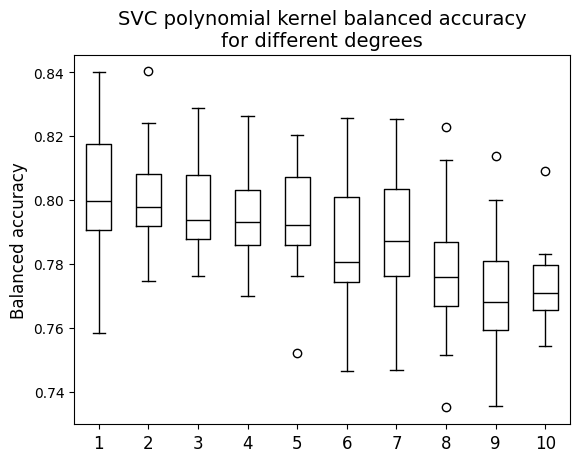

In [ ]:
fig_acc, ax_acc = mlcf.draw_boxplot(accuracies,ylabel='Balanced accuracy',
                                   title='SVC polynomial kernel balanced accuracy\nfor different degrees',
                                   xlabel_rotation=0,
                                   ha='center',
                                   )

ax_acc.set_xlabel('Polynomial Kernel Degree')

fig_acc.savefig('mlacca_outputs\\plots\\svm_opt\\svm_poly--kdeg--balanced_accuracy.svg',
                dpi=600, facecolor='#fff', bbox_inches='tight')

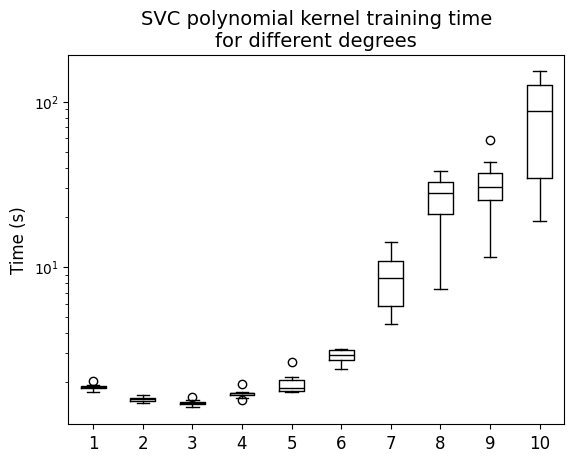

In [ ]:
fig_time, ax_time = mlcf.draw_boxplot(times,ylabel='Time (s)',
                                     title='SVC polynomial kernel training time\nfor different degrees',
                                     xlabel_rotation=0,
                                     ha='center',
                                     savepath='mlacca_outputs\\plots\\svm_opt\\svm_poly--kdeg--training_time.svg'
                                     )

ax_time.set_yscale('log')

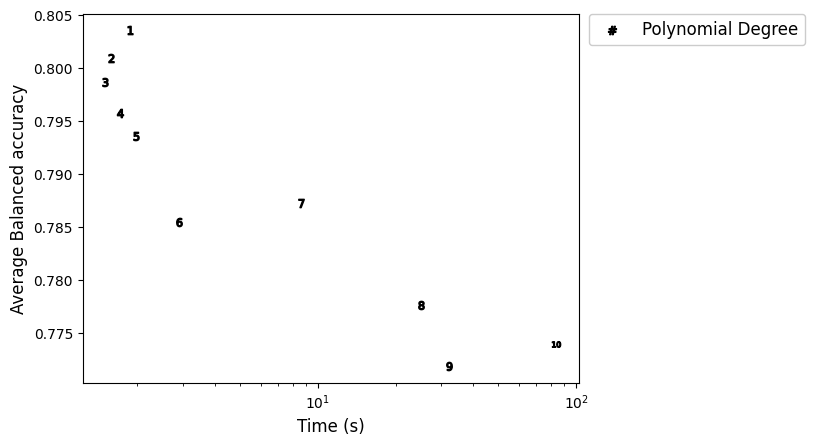

In [ ]:
fig_time_v_acc, ax_time_v_acc = plt.subplots()

for d in degrees:
    colour = mcolors.TABLEAU_COLORS[list(mcolors.TABLEAU_COLORS.keys())[np.where(degrees==d)[0][0]]]
    # ax_time_v_acc.scatter(times[d], accuracies[d], alpha=0.20,c=colour,)
    ax_time_v_acc.scatter(np.mean(times[d]), np.mean(accuracies[d]),
                          marker=f'${d}$',c='k',)

ax_time_v_acc.scatter([],[], label='Polynomial Degree',
                      marker='$\\#$',c='k',)

ax_time_v_acc.set_xlabel('Time (s)', fontsize=12)
ax_time_v_acc.set_ylabel('Average Balanced accuracy', fontsize=12)

ax_time_v_acc.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)

ax_time_v_acc.set_xscale('log')

fig_time_v_acc.savefig('mlacca_outputs\\plots\\svm_opt\\svm_poly--kdeg--balanced_accuracy_vs_time.svg',
                       dpi=600, facecolor='#fff', bbox_inches='tight')

KeyboardInterrupt: 

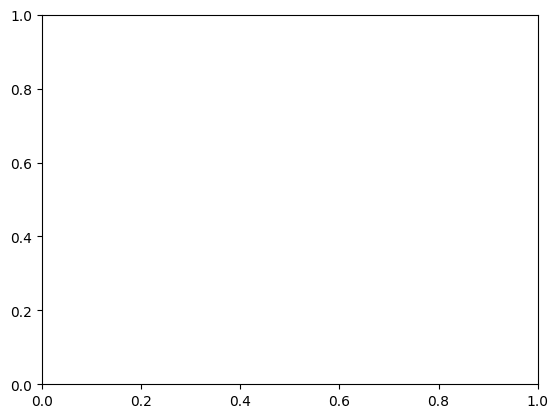

In [ ]:
# Visualise the effect of polynomial degree on the decision boundary

for d in degrees:
    mlcf.draw_decision_boundary_plot(CalibratedClassifierCV(SVC(kernel="poly",
                                                               degree=d,
                                                               gamma='auto',
                                                               probability=True)).fit(X_2d, y, sample_weight=weights if weighted else None),
                                    X_2d,
                                    np.unique(y),
                                    xlabel=columns_2d[0],
                                    ylabel=columns_2d[1],
                                    title=f'SVM (Polynomial Degree {d}) Decision Boundary\non van Krevelen Diagram',
                                    savepath=f'mlacca_outputs\\plots\\svm_opt\\svm_poly_deg{d}_vk_decision_boundary.svg',
                                    colors_dict=mlcf.vk_region_colours
                                    )

In [ ]:
# choose C and gamma hyperparameters for SVM with polynomial kernel for the 3D case
# https://www.geeksforgeeks.org/machine-learning/svm-hyperparameter-tuning-using-gridsearchcv-ml/

param_grid_svm_poly = {
    'C': [1, 10, 100, 1000],
    # 'gamma': [1/len(np.unique(y)), 1, 0.1, 0.01, 0.001, 0.0001],
    'degree': [1,2,3],
    }

grid = GridSearchCV(SVC(kernel='poly'),
                    param_grid_svm_poly, refit = True, verbose = 3) 
 
grid.fit(X_3d, y, sample_weight=weights if weighted else None)

print('3D SVM (poly) best_params_:', grid.best_params_) 
print('3D SVM (poly) best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.953 total time=   0.1s
[CV 2/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.889 total time=   0.1s
[CV 3/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.924 total time=   0.1s
[CV 4/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.835 total time=   0.1s
[CV 5/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.868 total time=   0.1s
[CV 1/5] END ............C=1, degree=1, gamma=1;, score=0.954 total time=   0.0s
[CV 2/5] END ............C=1, degree=1, gamma=1;, score=0.922 total time=   0.0s
[CV 3/5] END ............C=1, degree=1, gamma=1;, score=0.887 total time=   0.0s
[CV 4/5] END ............C=1, degree=1, gamma=1;, score=0.808 total time=   0.0s
[CV 5/5] END ............C=1, degree=1, gamma=1;, score=0.896 total time=   0.0s
[CV 1/5] END ..........C=1, degree=1, gamma=0.1;, score=0.938 total time=   0.2s
[CV 2/5] END ....

In [ ]:
# choose C and gamma hyperparameters for SVM with RBF kernel for the 2D case
# https://www.geeksforgeeks.org/machine-learning/svm-hyperparameter-tuning-using-gridsearchcv-ml/

param_grid_svm_rbf = {
    'C': [1, 10, 100, 1000],
    'gamma': [1/len(np.unique(y)), 1, 0.1, 0.01, 0.001, 0.0001],
    }

In [ ]:
grid = GridSearchCV(SVC(kernel='rbf',),
                    param_grid_svm_rbf, refit = True, verbose = 3) 

grid.fit(X_2d, y, sample_weight=weights if weighted else None)

print('2D SVM (RBF) best_params_:', grid.best_params_) 
print('2D SVM (RBF) best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END ....C=1, gamma=0.16666666666666666;, score=0.891 total time=   0.4s
[CV 2/5] END ....C=1, gamma=0.16666666666666666;, score=0.746 total time=   0.3s
[CV 3/5] END ....C=1, gamma=0.16666666666666666;, score=0.805 total time=   0.4s
[CV 4/5] END ....C=1, gamma=0.16666666666666666;, score=0.694 total time=   0.3s
[CV 5/5] END ....C=1, gamma=0.16666666666666666;, score=0.754 total time=   0.3s
[CV 1/5] END ......................C=1, gamma=1;, score=0.841 total time=   0.3s
[CV 2/5] END ......................C=1, gamma=1;, score=0.761 total time=   0.2s
[CV 3/5] END ......................C=1, gamma=1;, score=0.754 total time=   0.3s
[CV 4/5] END ......................C=1, gamma=1;, score=0.689 total time=   0.2s
[CV 5/5] END ......................C=1, gamma=1;, score=0.750 total time=   0.2s
[CV 1/5] END ....................C=1, gamma=0.1;, score=0.785 total time=   0.4s
[CV 2/5] END ....................C=1, gamma=0.1

In [ ]:
# choose C and gamma hyperparameters for SVM with RBF kernel for the 3D case
# https://www.geeksforgeeks.org/machine-learning/svm-hyperparameter-tuning-using-gridsearchcv-ml/

param_grid_svm_rbf = {
    'C': [1, 10, 100, 1000],
    'gamma': [1/len(np.unique(y)), 1, 0.1, 0.01, 0.001, 0.0001],
    }

grid = GridSearchCV(SVC(kernel='rbf',),
                    param_grid_svm_rbf, refit = True, verbose = 3) 

grid.fit(X_3d, y, sample_weight=weights if weighted else None)

print('3D SVM (RBF) best_params_:', grid.best_params_) 
print('3D SVM (RBF) best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END ....C=1, gamma=0.16666666666666666;, score=0.955 total time=   0.2s
[CV 2/5] END ....C=1, gamma=0.16666666666666666;, score=0.893 total time=   0.2s
[CV 3/5] END ....C=1, gamma=0.16666666666666666;, score=0.925 total time=   0.2s
[CV 4/5] END ....C=1, gamma=0.16666666666666666;, score=0.849 total time=   0.1s
[CV 5/5] END ....C=1, gamma=0.16666666666666666;, score=0.869 total time=   0.1s
[CV 1/5] END ......................C=1, gamma=1;, score=0.953 total time=   0.1s
[CV 2/5] END ......................C=1, gamma=1;, score=0.938 total time=   0.1s
[CV 3/5] END ......................C=1, gamma=1;, score=0.933 total time=   0.1s
[CV 4/5] END ......................C=1, gamma=1;, score=0.777 total time=   0.0s
[CV 5/5] END ......................C=1, gamma=1;, score=0.910 total time=   0.1s
[CV 1/5] END ....................C=1, gamma=0.1;, score=0.948 total time=   0.2s
[CV 2/5] END ....................C=1, gamma=0.1

In [22]:
# get parameters for models including PAHs

In [ ]:
df_with_pahs_path = 'mlacca_outputs\\csv_files\\new_vk_areas_with_pahs.csv'
df_with_pahs = pd.read_csv(df_with_pahs_path)

In [14]:
X_2d_with_pahs = df_with_pahs[columns_2d].to_numpy()
X_3d_with_pahs = df_with_pahs[columns_3d].to_numpy()

y_with_pahs = df_with_pahs['category'].to_numpy()

weighted_with_pahs = df_with_pahs['weights'].to_numpy() if weighted else None

In [17]:
X_2d_scaled = StandardScaler().fit_transform(X_2d_with_pahs)

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid_knn, refit = True, verbose = 3) 

grid.fit(X_2d_scaled, y_with_pahs)

print('2D KNN with PAHs best_params_:', grid.best_params_) 
print('2D KNN with PAHs best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END ...n_neighbors=10, weights=uniform;, score=0.896 total time=   0.0s
[CV 2/5] END ...n_neighbors=10, weights=uniform;, score=0.848 total time=   0.0s
[CV 3/5] END ...n_neighbors=10, weights=uniform;, score=0.940 total time=   0.0s
[CV 4/5] END ...n_neighbors=10, weights=uniform;, score=0.923 total time=   0.0s
[CV 5/5] END ...n_neighbors=10, weights=uniform;, score=0.892 total time=   0.0s
[CV 1/5] END ..n_neighbors=10, weights=distance;, score=0.903 total time=   0.0s
[CV 2/5] END ..n_neighbors=10, weights=distance;, score=0.843 total time=   0.0s
[CV 3/5] END ..n_neighbors=10, weights=distance;, score=0.937 total time=   0.0s
[CV 4/5] END ..n_neighbors=10, weights=distance;, score=0.924 total time=   0.0s
[CV 5/5] END ..n_neighbors=10, weights=distance;, score=0.888 total time=   0.0s
[CV 1/5] END ...n_neighbors=50, weights=uniform;, score=0.911 total time=   0.0s
[CV 2/5] END ...n_neighbors=50, weights=uniform;

In [19]:
X_3d_scaled = StandardScaler().fit_transform(X_3d_with_pahs)

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid_knn, refit = True, verbose = 3) 

grid.fit(X_3d_scaled, y_with_pahs)

print('3D KNN with PAHs best_params_:', grid.best_params_) 
print('3D KNN with PAHs best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END ...n_neighbors=10, weights=uniform;, score=0.914 total time=   0.0s
[CV 2/5] END ...n_neighbors=10, weights=uniform;, score=0.867 total time=   0.0s
[CV 3/5] END ...n_neighbors=10, weights=uniform;, score=0.984 total time=   0.0s
[CV 4/5] END ...n_neighbors=10, weights=uniform;, score=0.953 total time=   0.0s
[CV 5/5] END ...n_neighbors=10, weights=uniform;, score=0.947 total time=   0.0s
[CV 1/5] END ..n_neighbors=10, weights=distance;, score=0.905 total time=   0.0s
[CV 2/5] END ..n_neighbors=10, weights=distance;, score=0.863 total time=   0.0s
[CV 3/5] END ..n_neighbors=10, weights=distance;, score=0.980 total time=   0.0s
[CV 4/5] END ..n_neighbors=10, weights=distance;, score=0.965 total time=   0.0s
[CV 5/5] END ..n_neighbors=10, weights=distance;, score=0.945 total time=   0.0s
[CV 1/5] END ...n_neighbors=50, weights=uniform;, score=0.860 total time=   0.0s
[CV 2/5] END ...n_neighbors=50, weights=uniform;

In [ ]:
grid = GridSearchCV(SVC(kernel='poly',),
                    param_grid_svm_poly, refit = True, verbose = 3) 

grid.fit(X_2d_with_pahs, y_with_pahs, sample_weight=weighted_with_pahs if weighted else None)

print('2D SVM (poly) with PAHs best_params_:', grid.best_params_) 
print('2D SVM (poly) with PAHs best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.829 total time=   0.2s
[CV 2/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.826 total time=   0.2s
[CV 3/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.810 total time=   0.3s
[CV 4/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.829 total time=   0.2s
[CV 5/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.823 total time=   0.3s
[CV 1/5] END ............C=1, degree=1, gamma=1;, score=0.861 total time=   0.1s
[CV 2/5] END ............C=1, degree=1, gamma=1;, score=0.814 total time=   0.1s
[CV 3/5] END ............C=1, degree=1, gamma=1;, score=0.862 total time=   0.2s
[CV 4/5] END ............C=1, degree=1, gamma=1;, score=0.818 total time=   0.2s
[CV 5/5] END ............C=1, degree=1, gamma=1;, score=0.804 total time=   0.1s
[CV 1/5] END ..........C=1, degree=1, gamma=0.1;, score=0.825 total time=   0.3s
[CV 2/5] END ....

In [ ]:
grid = GridSearchCV(SVC(kernel='poly',),
                    param_grid_svm_poly, refit = True, verbose = 3) 

grid.fit(X_3d_with_pahs, y_with_pahs, sample_weight=weighted_with_pahs if weighted else None)

print('3D SVM (poly) with PAHs best_params_:', grid.best_params_) 
print('3D SVM (poly) with PAHs best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.903 total time=   0.1s
[CV 2/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.900 total time=   0.1s
[CV 3/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.940 total time=   0.2s
[CV 4/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.903 total time=   0.1s
[CV 5/5] END C=1, degree=1, gamma=0.16666666666666666;, score=0.906 total time=   0.1s
[CV 1/5] END ............C=1, degree=1, gamma=1;, score=0.928 total time=   0.0s
[CV 2/5] END ............C=1, degree=1, gamma=1;, score=0.915 total time=   0.0s
[CV 3/5] END ............C=1, degree=1, gamma=1;, score=0.959 total time=   0.1s
[CV 4/5] END ............C=1, degree=1, gamma=1;, score=0.899 total time=   0.0s
[CV 5/5] END ............C=1, degree=1, gamma=1;, score=0.939 total time=   0.0s
[CV 1/5] END ..........C=1, degree=1, gamma=0.1;, score=0.902 total time=   0.2s
[CV 2/5] END ....

In [ ]:
grid = GridSearchCV(SVC(kernel='rbf',),
                    param_grid_svm_rbf, refit = True, verbose = 3) 

grid.fit(X_2d_with_pahs, y_with_pahs, sample_weight=weighted_with_pahs if weighted else None)

print('2D SVM (RBF) with PAHs best_params_:', grid.best_params_) 
print('2D SVM (RBF) with PAHs best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END ....C=1, gamma=0.16666666666666666;, score=0.833 total time=   0.4s
[CV 2/5] END ....C=1, gamma=0.16666666666666666;, score=0.838 total time=   0.3s
[CV 3/5] END ....C=1, gamma=0.16666666666666666;, score=0.820 total time=   0.4s
[CV 4/5] END ....C=1, gamma=0.16666666666666666;, score=0.808 total time=   0.4s
[CV 5/5] END ....C=1, gamma=0.16666666666666666;, score=0.819 total time=   0.4s
[CV 1/5] END ......................C=1, gamma=1;, score=0.879 total time=   0.2s
[CV 2/5] END ......................C=1, gamma=1;, score=0.834 total time=   0.2s
[CV 3/5] END ......................C=1, gamma=1;, score=0.802 total time=   0.3s
[CV 4/5] END ......................C=1, gamma=1;, score=0.812 total time=   0.2s
[CV 5/5] END ......................C=1, gamma=1;, score=0.809 total time=   0.2s
[CV 1/5] END ....................C=1, gamma=0.1;, score=0.829 total time=   0.4s
[CV 2/5] END ....................C=1, gamma=0.1

In [ ]:
grid = GridSearchCV(SVC(kernel='rbf',),
                    param_grid_svm_rbf, refit = True, verbose = 3) 

grid.fit(X_3d_with_pahs, y_with_pahs, sample_weight=weighted_with_pahs if weighted else None)

print('3D SVM (RBF) with PAHs best_params_:', grid.best_params_) 
print('3D SVM (RBF) with PAHs best_estimator_:', grid.best_estimator_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END ....C=1, gamma=0.16666666666666666;, score=0.917 total time=   0.2s
[CV 2/5] END ....C=1, gamma=0.16666666666666666;, score=0.909 total time=   0.2s
[CV 3/5] END ....C=1, gamma=0.16666666666666666;, score=0.968 total time=   0.2s
[CV 4/5] END ....C=1, gamma=0.16666666666666666;, score=0.891 total time=   0.2s
[CV 5/5] END ....C=1, gamma=0.16666666666666666;, score=0.935 total time=   0.2s
[CV 1/5] END ......................C=1, gamma=1;, score=0.921 total time=   0.1s
[CV 2/5] END ......................C=1, gamma=1;, score=0.936 total time=   0.1s
[CV 3/5] END ......................C=1, gamma=1;, score=0.963 total time=   0.1s
[CV 4/5] END ......................C=1, gamma=1;, score=0.918 total time=   0.1s
[CV 5/5] END ......................C=1, gamma=1;, score=0.909 total time=   0.1s
[CV 1/5] END ....................C=1, gamma=0.1;, score=0.917 total time=   0.2s
[CV 2/5] END ....................C=1, gamma=0.1